In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time

In [ ]:
(x_train, y_train), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
def preprocess_data(images):
    # Normalize images to [-1, 1] range
    images = (images - 127.5) / 127.5
    images = images.reshape(images.shape[0], 28, 28, 1)
    return images

def explore_dataset():
    # Print basic information
    print(f"Dataset shape: {x_train.shape}")
    print(f"Number of samples: {len(x_train)}")

    class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                   'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
    unique, counts = np.unique(y_train, return_counts=True)
    for class_id, count in zip(unique, counts):
        print(f"{class_names[class_id]}: {count} samples")

    # Visualize sample images
    plt.figure(figsize=(10, 10))
    for i in range(25):
        plt.subplot(5, 5, i + 1)
        plt.imshow(x_train[i], cmap='gray')
        plt.axis('off')
        plt.title(class_names[y_train[i]])
    plt.tight_layout()
    plt.show()

In [ ]:
def build_generator():
    model = tf.keras.Sequential([
        #foundation for 7x7 feature maps
        tf.keras.layers.Dense(7*7*256, use_bias=False, input_shape=(100,)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),
        tf.keras.layers.Reshape((7, 7, 256)),
        #upsampling to 14x14
        tf.keras.layers.Conv2DTranspose(128, (5, 5), strides=(2, 2),
                                      padding='same', use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),
        #upsampling to 28x28
        tf.keras.layers.Conv2DTranspose(64, (5, 5), strides=(2, 2),
                                      padding='same', use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(),

        tf.keras.layers.Conv2DTranspose(1, (5, 5), strides=(1, 1),
                                      padding='same', use_bias=False,
                                      activation='tanh')
    ])
    return model

In [ ]:
def build_discriminator():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same',
                             input_shape=[28, 28, 1]),
        tf.keras.layers.LeakyReLU(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'),
        tf.keras.layers.LeakyReLU(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(1)
    ])
    return model

In [ ]:
class GAN:
    def __init__(self):
        self.generator = build_generator()
        self.discriminator = build_discriminator()
        self.cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)
        self.generator_optimizer = tf.keras.optimizers.Adam(1e-4)
        self.discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)
        self.generator_losses = []
        self.discriminator_losses = []

    @tf.function
    def train_step(self, real_images, batch_size):
        noise = tf.random.normal([batch_size, 100])

        with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
            generated_images = self.generator(noise, training=True)

            real_output = self.discriminator(real_images, training=True)
            fake_output = self.discriminator(generated_images, training=True)

            gen_loss = self.generator_loss(fake_output)
            disc_loss = self.discriminator_loss(real_output, fake_output)

        gradients_of_generator = gen_tape.gradient(
            gen_loss, self.generator.trainable_variables)
        gradients_of_discriminator = disc_tape.gradient(
            disc_loss, self.discriminator.trainable_variables)

        self.generator_optimizer.apply_gradients(
            zip(gradients_of_generator, self.generator.trainable_variables))
        self.discriminator_optimizer.apply_gradients(
            zip(gradients_of_discriminator, self.discriminator.trainable_variables))

        return gen_loss, disc_loss

    def generator_loss(self, fake_output):
        return self.cross_entropy(tf.ones_like(fake_output), fake_output)

    def discriminator_loss(self, real_output, fake_output):
        real_loss = self.cross_entropy(tf.ones_like(real_output), real_output)
        fake_loss = self.cross_entropy(tf.zeros_like(fake_output), fake_output)
        total_loss = real_loss + fake_loss
        return total_loss

    def train(self, dataset, epochs, batch_size=256):
        for epoch in range(epochs):
            start = time.time()
            gen_loss_list = []
            disc_loss_list = []

            for batch in dataset:
                gen_loss, disc_loss = self.train_step(batch, batch_size)
                gen_loss_list.append(gen_loss)
                disc_loss_list.append(disc_loss)

            self.generator_losses.append(tf.reduce_mean(gen_loss_list))
            self.discriminator_losses.append(tf.reduce_mean(disc_loss_list))

            if (epoch + 1) % 10 == 0:
                print(f'Epoch {epoch+1}, Gen Loss: {self.generator_losses[-1]:.4f}, '
                      f'Disc Loss: {self.discriminator_losses[-1]:.4f}, '
                      f'Time: {time.time()-start:.2f} sec')
                self.generate_and_save_images(epoch + 1)

    def generate_and_save_images(self, epoch):
        noise = tf.random.normal([16, 100])
        generated_images = self.generator(noise, training=False)

        plt.figure(figsize=(4, 4))
        for i in range(16):
            plt.subplot(4, 4, i + 1)
            plt.imshow(generated_images[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
            plt.axis('off')
        plt.show()

    def plot_losses(self):
        plt.figure(figsize=(10, 5))
        plt.plot(self.generator_losses, label='Generator Loss')
        plt.plot(self.discriminator_losses, label='Discriminator Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

Dataset shape: (60000, 28, 28)
Number of samples: 60000
T-shirt/top: 6000 samples
Trouser: 6000 samples
Pullover: 6000 samples
Dress: 6000 samples
Coat: 6000 samples
Sandal: 6000 samples
Shirt: 6000 samples
Sneaker: 6000 samples
Bag: 6000 samples
Ankle boot: 6000 samples


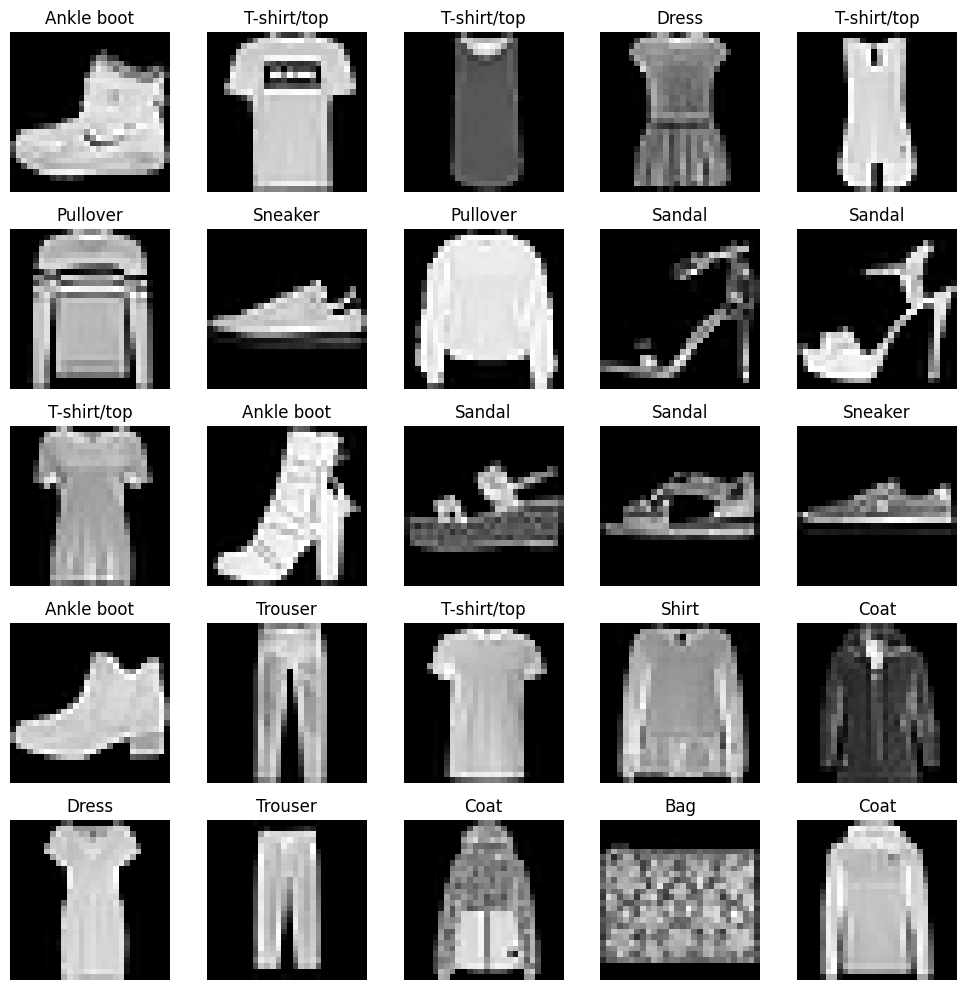

In [ ]:
explore_dataset()

In [ ]:
#Prepare the training data
BATCH_SIZE = 256
train_images = preprocess_data(x_train)
train_dataset = tf.data.Dataset.from_tensor_slices(train_images)\
    .shuffle(60000).batch(BATCH_SIZE)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 10, Gen Loss: 0.7432, Disc Loss: 1.3472, Time: 21.06 sec


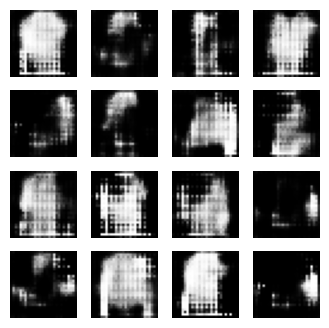

Epoch 20, Gen Loss: 0.9450, Disc Loss: 1.2235, Time: 21.04 sec


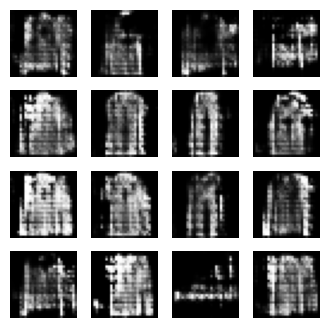

Epoch 30, Gen Loss: 0.9304, Disc Loss: 1.2142, Time: 21.03 sec


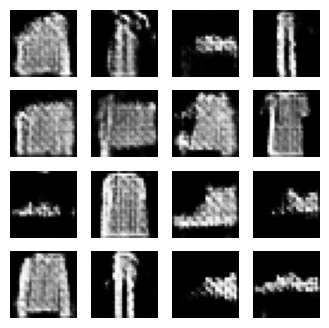

Epoch 40, Gen Loss: 0.9956, Disc Loss: 1.1838, Time: 21.03 sec


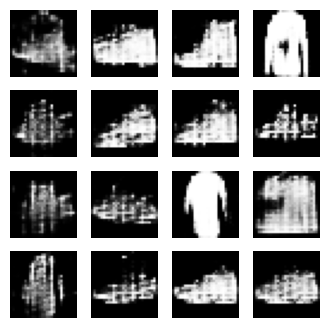

Epoch 50, Gen Loss: 0.9248, Disc Loss: 1.2316, Time: 21.01 sec


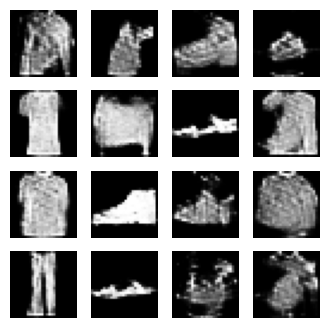

In [ ]:
#Create and train the GAN
gan = GAN()
EPOCHS = 50
gan.train(train_dataset, EPOCHS)

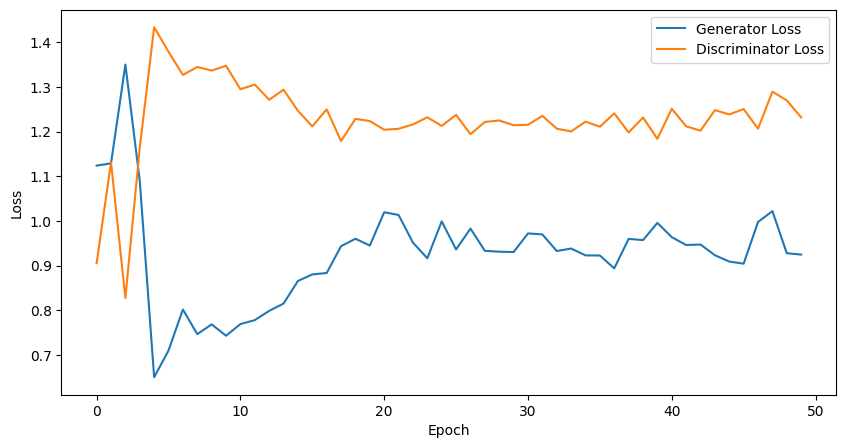

In [ ]:
gan.plot_losses()

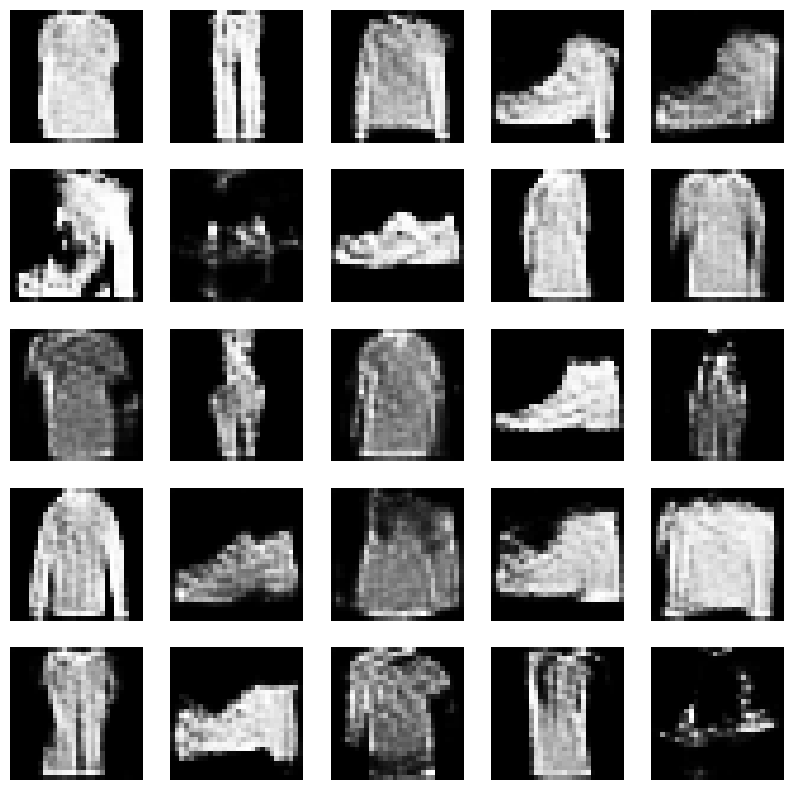

In [ ]:
#Generate final images
noise = tf.random.normal([25, 100])
generated_images = gan.generator(noise, training=False)
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(generated_images[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
    plt.axis('off')
plt.show()